# 03 - Dataset Generation

Creates a structured baseline dataset suitable for downstream analysis and paper figures.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.production_model import ProductionUnit, STATE_NAMES
from core.network_model import InformationNetwork
from core.reliability_model import transmission_accuracy, rolling_failure_rate
from core.simulation_engine import SimulationEngine, SimulationConfig, summarize_by_time, performance_summary

OUTPUT_DIR = PROJECT_ROOT / 'outputs'
DATASET_DIR = OUTPUT_DIR / 'datasets'
GRAPH_DIR = OUTPUT_DIR / 'graphs'
LOG_DIR = OUTPUT_DIR / 'logs'
for directory in [DATASET_DIR, GRAPH_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
raw_path = DATASET_DIR / 'baseline_raw_runs.csv'
if raw_path.exists():
    raw = pd.read_csv(raw_path)
else:
    raw = SimulationEngine(SimulationConfig()).run(steps=600, runs=150, mode='baseline', seed=2026)

raw['rolling_reliability_25'] = raw.groupby('run')['reliability'].transform(lambda s: s.rolling(25, min_periods=1).mean())
raw['rolling_production_25'] = raw.groupby('run')['production_rate'].transform(lambda s: s.rolling(25, min_periods=1).mean())
raw['failure_event'] = ((raw['failure'] == 1.0) & (raw.groupby('run')['failure'].shift(fill_value=0.0) == 0.0)).astype(int)

dataset = raw[[
    'time', 'run', 'unit_state_vector', 'avg_load', 'max_load', 'gateway_load',
    'transmission_accuracy', 'production_rate', 'throughput', 'reliability',
    'rolling_reliability_25', 'rolling_production_25', 'failure_event'
]].copy()

dataset.to_csv(DATASET_DIR / 'baseline_dataset.csv', index=False)
print('Saved', DATASET_DIR / 'baseline_dataset.csv')
dataset.head()

Saved /Users/ketantripathi/codes/ICC/iot_project/outputs/datasets/baseline_dataset.csv


,time,run,unit_state_vector,avg_load,max_load,gateway_load,transmission_accuracy,production_rate,throughput,reliability,rolling_reliability_25,rolling_production_25,failure_event
0,0,0,"[2, 3, 2, 2]",3.378821,8.773827,8.773827,0.286104,1.023459,0.292816,1.0,1.0,1.023459,0
1,1,0,"[3, 3, 2, 1]",3.357048,8.649425,8.649425,0.286067,1.012800,0.289728,1.0,1.0,1.018129,0
2,2,0,"[2, 3, 1, 0]",2.781317,7.146211,7.146211,0.383027,1.001987,0.383788,1.0,1.0,1.012749,0
3,3,0,"[2, 1, 1, 0]",2.499738,6.543024,6.543024,0.434692,0.971925,0.422488,1.0,1.0,1.002543,0
4,4,0,"[2, 1, 2, 2]",3.075314,7.984173,7.984173,0.324381,1.032406,0.334893,1.0,1.0,1.008515,0


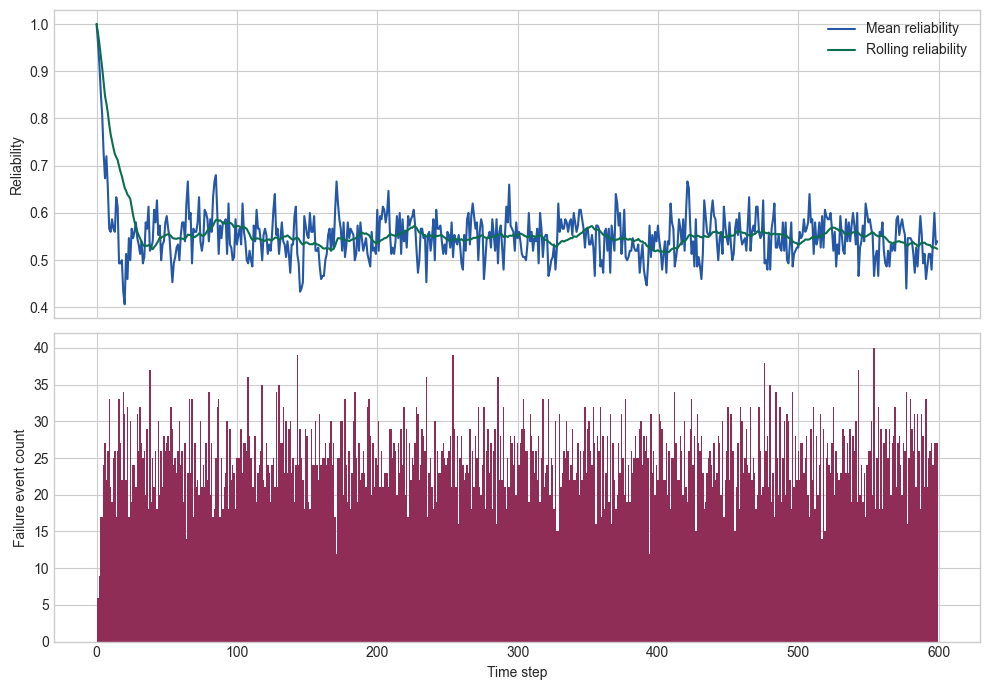

In [3]:
summary = dataset.groupby('time', as_index=False).agg({
    'reliability': 'mean',
    'rolling_reliability_25': 'mean',
    'failure_event': 'sum',
    'gateway_load': 'mean',
})
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(summary['time'], summary['reliability'], label='Mean reliability', color='#2457a6')
axes[0].plot(summary['time'], summary['rolling_reliability_25'], label='Rolling reliability', color='#0b6e4f')
axes[0].legend()
axes[0].set_ylabel('Reliability')
axes[1].bar(summary['time'], summary['failure_event'], color='#8f2d56', width=1.0)
axes[1].set_ylabel('Failure event count')
axes[1].set_xlabel('Time step')
fig.tight_layout()
fig.savefig(GRAPH_DIR / '03_dataset_diagnostics.png', dpi=160)
plt.show()